Est il possible de déterminer le niveau d'un joueur d'échec dès les premiers coups d'une partie ? C'est ce que nous allons essayer de déterminer à partir des ouvertures utilisées par un échantillon de joueurs Français sur Chess.com.

# Prélevement de l'échantillon

Nous avons constitué un échantillon de joueurs grâce à l'api de Chess.com https://api.chess.com/pub. 2tant donné que les classement par élo est trop volatil, nous avons décidé de rangé les joueurs en 5 classes de niveaux. Les débutants ont moins de 800 élos, les intermediaires vont jusqu'à 1200, les avancés jusqu'à 1600 et les experts jusqu'à 2200 élos. Passé ce cap, les joueurs avec autant d'élos se font rare alors nous avons séléctionné les individus de la classe maîtres grâce aux titres associés sur Chess.com à ces joueurs (par exemple IM : Internationnal Master).

Nous avons retenu aléatoirement 40 joueurs par classe qui ont effectué au moins 20 parties rapide de 10 min pendnat le mois de mars 2026. Ces 200 joueurs constituent le csv **players_mars_2026.csv** (construite dans imports.py).

Nous avons ensuite enregistré les ouvertures préférées, le temps moyen consacré aux premiers coups et les ouvertures qui apportent le plus souvent la victoire pour tous les joueurs : **stat_parties.parquet** (construite dans games.py).

# Chargement des données

In [2]:
from src.analyse_descriptive import *

df_joueurs = pd.read_csv("data/players_mars_2026.csv")
df_parties = pd.read_parquet("data/stat_parties.parquet")

# Rating 

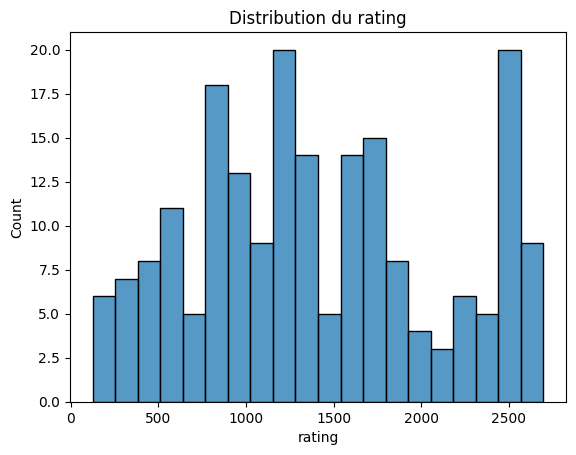

In [3]:
plot_rating(df_joueurs)

Voici la repartition des joueurs de l'échantillon selon leur élo.

# Activité

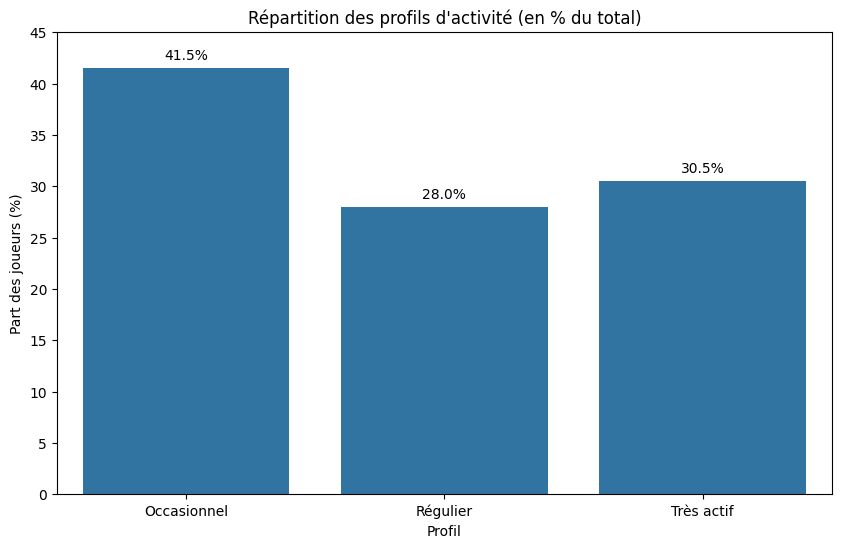

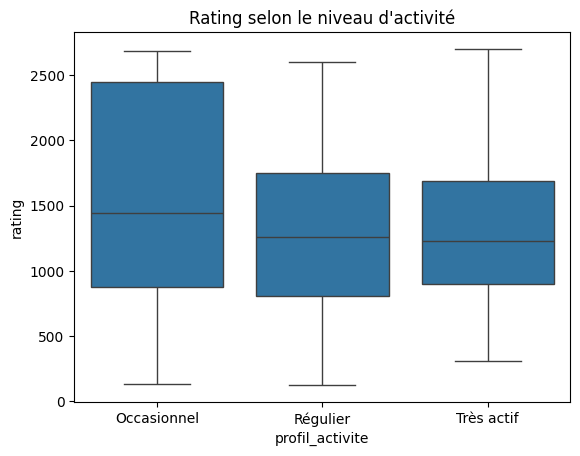

In [4]:
df_joueurs = add_activity_profile(df_joueurs)

plot_activity(df_joueurs)
plot_activity_vs_rating(df_joueurs)

Tous les joueurs sélectionnés ne jouent pas à la même fréquence. 41,5% d'entre eux sont des joueurs occasionnels qui ont joué moins de 50 fois en mars tandis que 30,5% d'entre eux jouent à ce mode de joue plus de 100 fois en mars 2026. Les joueurs dit occasionnels semblent avoir un meilleur niveau, mais cela s'explique surment parce que le mode de jeu en 1O min n'est pas le mode préféré des meilleurs joueurs.

# Style de jeu

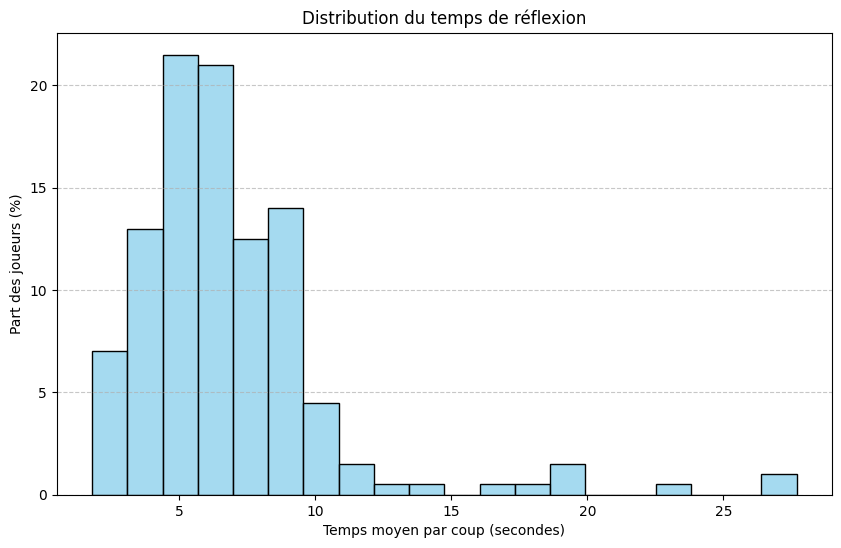

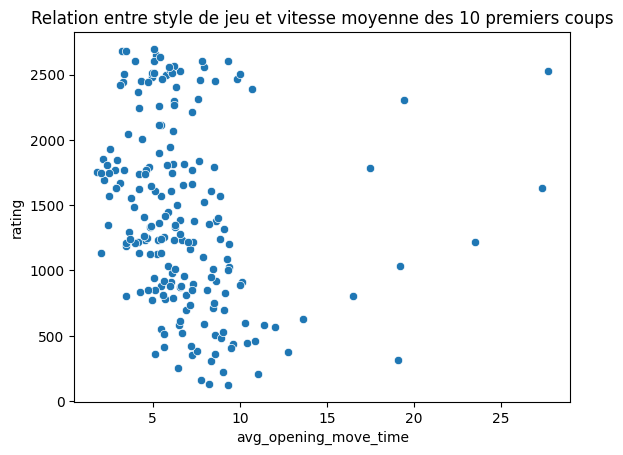

In [5]:
plot_time_distribution(df_parties)
plot_time_vs_speed(df_parties) 

Plus de 40% des joueurs passent entre 5 et 6 secondes par coups en moyenne sur leur 10 premiers coups.
Le nuage de points semble indiquer que les joueurs plus forts ne sont pas tellement plus rapide que les moins bons.

<Figure size 1400x800 with 0 Axes>

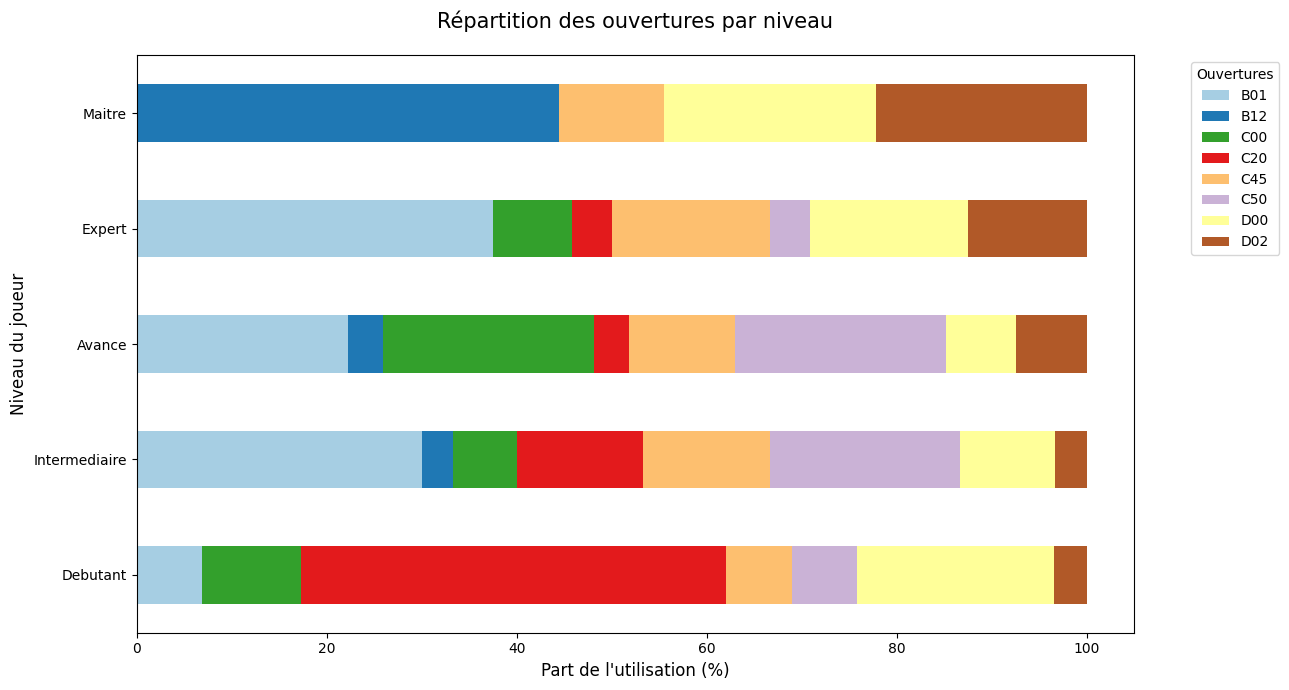

In [6]:
plot_opening_distribution_by_class(df_parties)

L'ouverture la plus utilisée chez les mâitres est  B12.

# Entrainement du modele de random forest

Essayons maintenant de déterminer la classe de niveau à laquelle appartient un joueur selon sa vitesse de jeu, selon les ouvertures utilisées le plus souvent, et les ouvertures qui le font le plus gagner.

L'API de Chess.com associe à chaque partie un code ECO qui détermine l'ouverture utilisée dasn la partie.
Dans un premier temps nous avons utilisé de manière brut ces codes ECO avant de les classer par famille. En effet il existe 600 ouvertures ECO et cela a pu empêcher des joueurs d'être associés à d'autres joueurs si l'ouverture n'est pas exactement la même. Cependant, regrouper les ouvertures en familles peut avoir des conséquences mauvaises pour notre classification si une variance d'une famille et utlisiée uniquement par les maîtres alors qu'une très similaire n'est utilisée que par les débutants.

Configuration

In [7]:
import sys
sys.path.append('../')
from src.pipeline import ChessClassifier

# Initialisation du pipeline
clf = ChessClassifier('data/stat_parties.parquet', random_state=42)

In [8]:
summary = clf.get_data_summary()



Nombre total de joueurs : 200
Nombre de caractéristiques : 26
Répartition Train/Test  : 160 / 40
Distribution des classes :
  - Debutant     : 40 (20.0%)
  - Intermediaire: 40 (20.0%)
  - Avance       : 40 (20.0%)
  - Expert       : 40 (20.0%)
  - Maitre       : 40 (20.0%)


Étape 1 : Optimisation des hyperparamètres

In [15]:
cv_results = clf.cross_validate(cv_folds=5)

print(f"Accuracy : {cv_results['accuracy_mean']:.3f} (±{cv_results['accuracy_std']:.3f})")
print(f"F1-Score : {cv_results['f1_mean']:.3f} (±{cv_results['f1_std']:.3f})")

Accuracy : 0.475 (±0.031)
F1-Score : 0.458 (±0.041)


Recherche par GridSearchCV

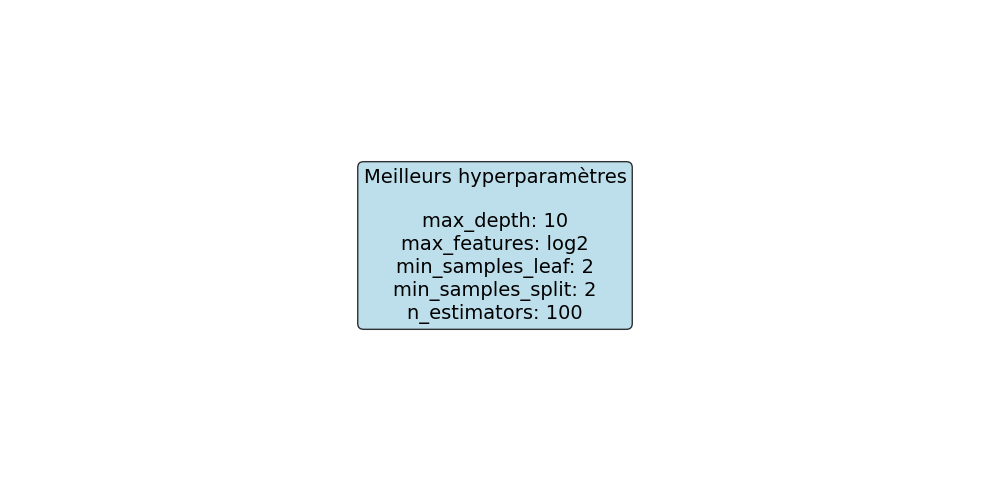

{'max_depth': 10,
 'max_features': 'log2',
 'min_samples_leaf': 2,
 'min_samples_split': 2,
 'n_estimators': 100}

In [10]:
best_params, best_score = clf.tune_hyperparameters(cv_folds=5, verbose=0)

clf.plot_hyperparameter_results()

Étape 2 : Entraînement du modèle final

In [17]:
metrics = clf.train_final_model()
clf.train_final_model(best_params)

{'train_accuracy': 0.925,
 'test_accuracy': 0.45,
 'test_f1': 0.4478195488721804,
 'overfitting': 0.47500000000000003}

Ici il n'y pas de risque à détecter de faux positifs ou de faux négatifs, mais dasn tous les cas les test d'accuracy et de F1 sont tout aussi mauvais.

Étape 3 : Importance des features

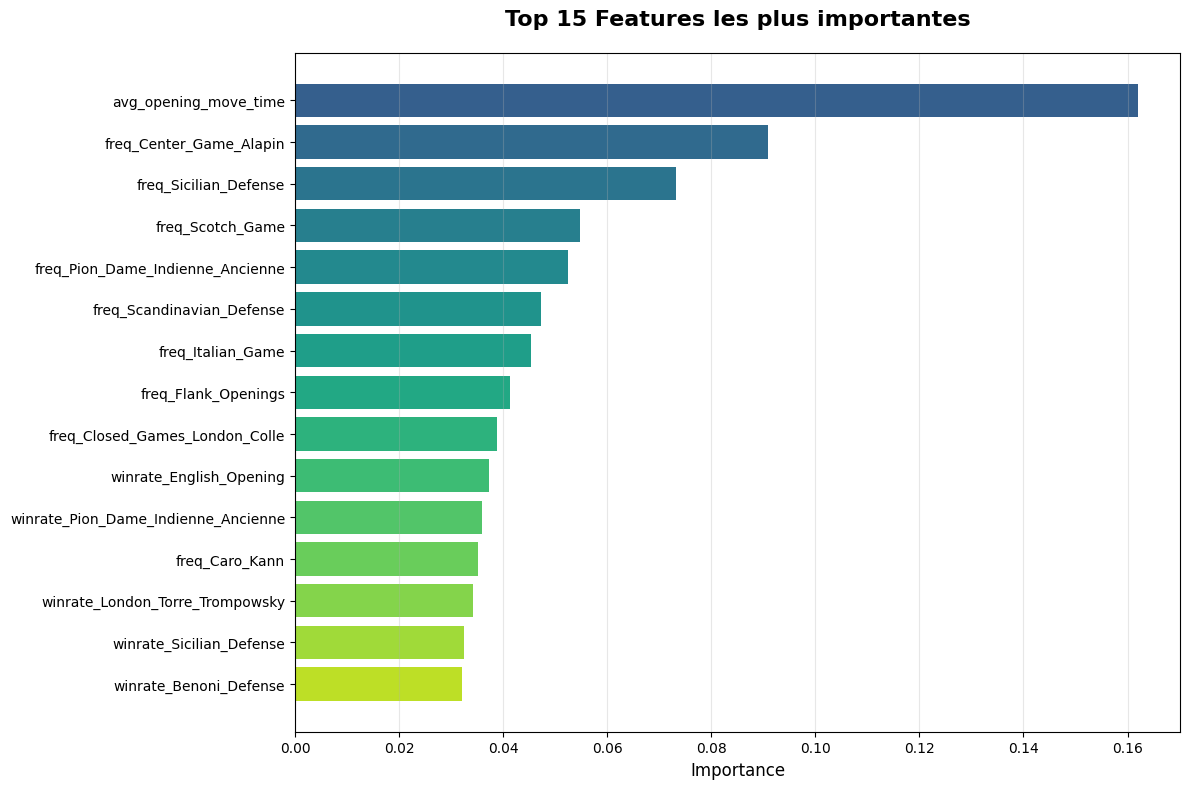

In [12]:
top_features = clf.plot_feature_importance(top_n=15, save_path='feature_importance.png')

Malgre le graphique vu plus haut, la vitesse de jeu dan sles 10 premiers coups semble être l'élement le plus determinant de l'appartenance à une classe.

Étape 4 : Matrice de confusion

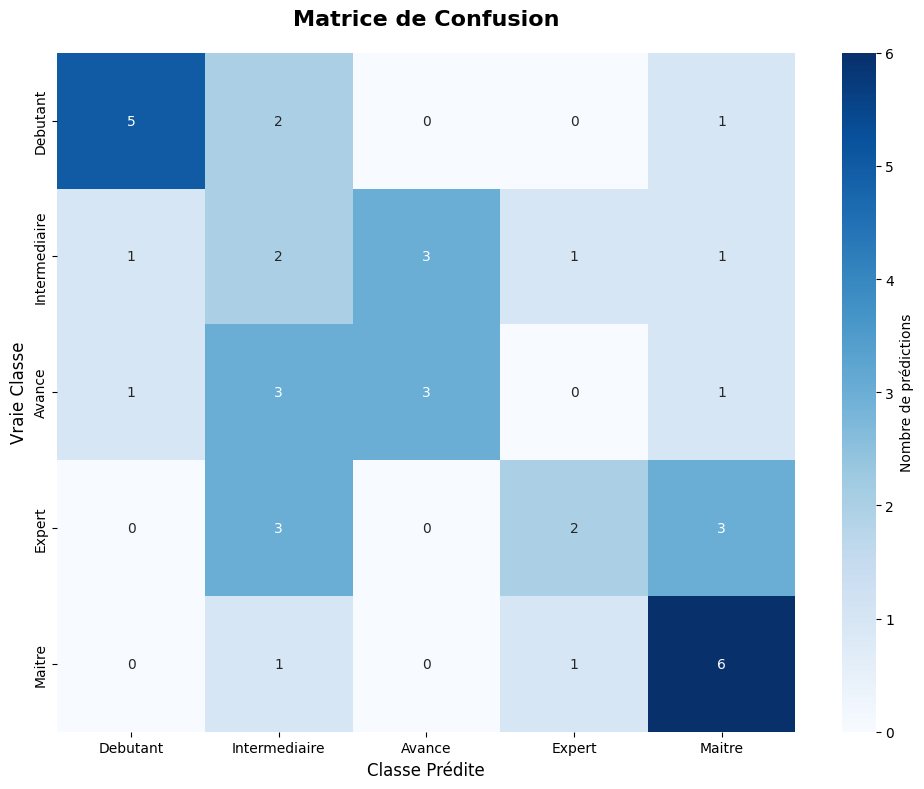

In [13]:
clf.plot_confusion_matrix(figsize=(10, 8), save_path='confusion_matrix.png')

Le modele n'est acceptable que pour prédire les débutants et les mâitres, mais il est très mauvais pour prédire le reste.

Visualisation d'un arbre


🎓 Modèle Random Forest
  Arbres            : 100
  Profondeur max    : 10
  Min samples split : 2


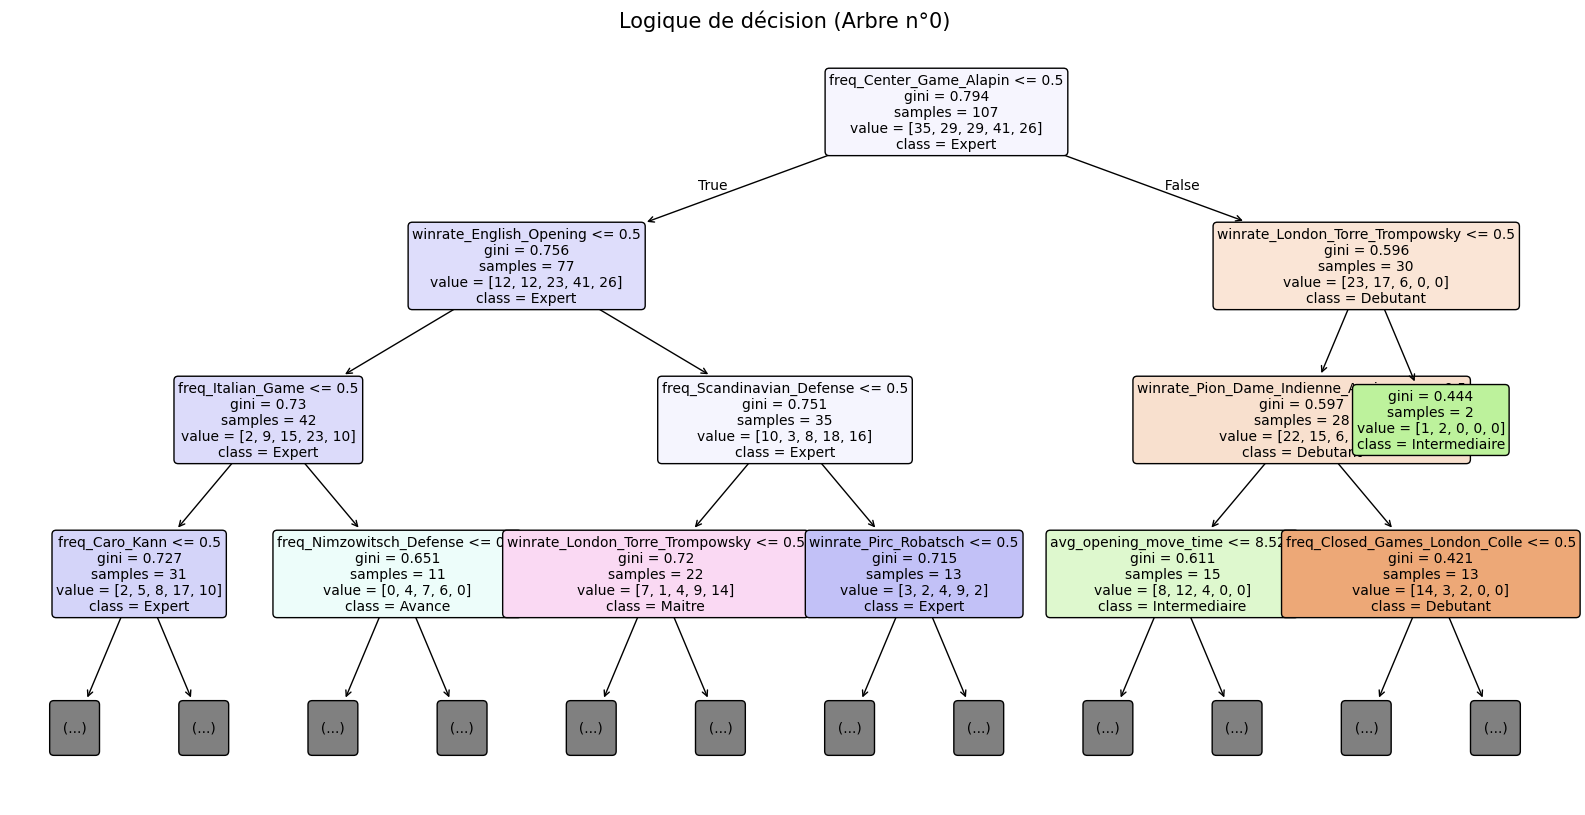

In [14]:
print(f"\n🎓 Modèle Random Forest")
print(f"  Arbres            : {best_params['n_estimators']}")
print(f"  Profondeur max    : {best_params['max_depth']}")
print(f"  Min samples split : {best_params['min_samples_split']}")

clf.visualize_one_tree(tree_index=0, max_depth=3)
clf.save_model('models/random_forest_final.pkl')

Pour conclure, les ouvertures utilisées ne suffisent pas à prédire le niveau d'un joueur, il faudrait ajouter d'autres parametre comme la précision des coups, ou bien regarder le niveau qu'on les joueurs dans d'autres modes de jeux par exemple.